In [7]:
import pandas as pd

In [8]:
df = pd.read_csv(r"C:\Users\DELL\Desktop\task 4\twitter_training.csv")

In [9]:
df.head()

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [10]:
df.shape

(74681, 4)

In [11]:
df.columns

Index(['2401', 'Borderlands', 'Positive',
       'im getting on borderlands and i will murder you all ,'],
      dtype='str')

In [13]:
df.head()
df.shape
df.columns

Index(['2401', 'Borderlands', 'Positive',
       'im getting on borderlands and i will murder you all ,'],
      dtype='str')

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74681 entries, 0 to 74680
Data columns (total 4 columns):
 #   Column                                                 Non-Null Count  Dtype
---  ------                                                 --------------  -----
 0   2401                                                   74681 non-null  int64
 1   Borderlands                                            74681 non-null  str  
 2   Positive                                               74681 non-null  str  
 3   im getting on borderlands and i will murder you all ,  73995 non-null  str  
dtypes: int64(1), str(3)
memory usage: 2.3 MB


In [16]:
df.iloc[:, 2].value_counts()

Positive
Negative      22542
Positive      20831
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64

In [17]:
df = df[df.iloc[:, 2] != "Irrelevant"]

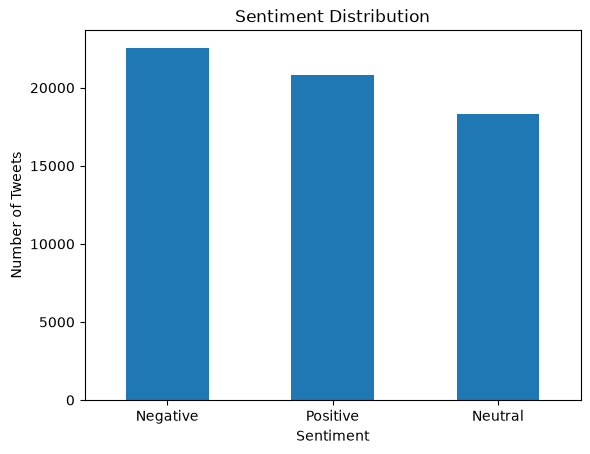

In [19]:
sentiment_counts = df.iloc[:, 2].value_counts()

sentiment_counts.plot(kind="bar")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=0)
plt.show()

In [21]:
%pip install nltk

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----------- ---------------------------- 0.5/1.8 MB 334.8 kB/s eta 0:00:04
   ----------- ---------------------------- 0.5/1.8 MB 334.8 kB/s eta 0:00:04
   ----------- ---------------------------- 0.5/1.8 MB 334.8 kB/s eta 0:00:04
   ----------- ---------------------------- 0.5/1.8 MB 334.8 kB/s eta 0:00:04
   ----------- ---------------------------- 0.5/1.8 MB 334.8 kB/s e

In [23]:
import nltk

In [26]:
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [27]:
stop_words = set(stopwords.words("english"))

In [29]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    
    return " ".join(tokens)

In [32]:
df["clean_text"] = df.iloc[:, 3].apply(clean_text)

In [33]:
df[[df.columns[3], "clean_text"]].head()


,"im getting on borderlands and i will murder you all ,",clean_text
0,I am coming to the borders and I will kill you...,coming borders kill
1,im getting on borderlands and i will kill you ...,im getting borderlands kill
2,im coming on borderlands and i will murder you...,im coming borderlands murder
3,im getting on borderlands 2 and i will murder ...,im getting borderlands murder
4,im getting into borderlands and i can murder y...,im getting borderlands murder


## TF-IDF Vectorization

TF-IDF (Term Frequency-Inverse Document Frequency) converts text into numerical features that can be used by machine learning models. It gives more importance to words that are frequent in a particular text but less common across the entire dataset.

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [35]:
X = df["clean_text"]
y = df.iloc[:, 2]

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [37]:
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [38]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(49352, 5000)
(12339, 5000)


In [39]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](3,)","[18033.,14654.,16665.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](3,)","[-1.01,-1.21,-1.09]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[<U8](3,)","['Negative','Neutral','Positive']"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](3, 5000)","[[ 2.66,10.13, 2.99,..., 0.85, 4.04, 8.14], [ 0. , 0.99, 1.6 ,..., 5.55, 4.59, 0. ], [ 2.27, 0.25, 2.07,..., 0.89, 5.62, 0. ]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](3, 5000)","[[ -9.59, -8.48, -9.51,...,-10.27, -9.27, -8.68], [-10.69,-10. , -9.73,..., -8.81, -8.97,-10.69], [ -9.56,-10.52, -9.63,...,-10.11, -8.86,-10.75]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5000


In [40]:
nb_pred = nb_model.predict(X_test_tfidf)

print(nb_pred[:10])

['Negative' 'Negative' 'Positive' 'Positive' 'Negative' 'Negative'
 'Negative' 'Positive' 'Positive' 'Negative']


In [41]:
from sklearn.metrics import accuracy_score, classification_report

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))

print("\nNaive Bayes Classification Report:")
print(classification_report(y_test, nb_pred))

Naive Bayes Accuracy: 0.7079179836291434

Naive Bayes Classification Report:
              precision    recall  f1-score   support

    Negative       0.70      0.81      0.75      4509
     Neutral       0.73      0.55      0.63      3664
    Positive       0.71      0.74      0.72      4166

    accuracy                           0.71     12339
   macro avg       0.71      0.70      0.70     12339
weighted avg       0.71      0.71      0.70     12339



In [42]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_tfidf, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [43]:
lr_pred = lr_model.predict(X_test_tfidf)

print(lr_pred[:10])

['Negative' 'Negative' 'Positive' 'Positive' 'Neutral' 'Negative'
 'Negative' 'Positive' 'Positive' 'Neutral']


In [44]:
from sklearn.metrics import accuracy_score, classification_report

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.7511953967096199

Logistic Regression Classification Report:
              precision    recall  f1-score   support

    Negative       0.78      0.80      0.79      4509
     Neutral       0.69      0.69      0.69      3664
    Positive       0.77      0.75      0.76      4166

    accuracy                           0.75     12339
   macro avg       0.75      0.75      0.75     12339
weighted avg       0.75      0.75      0.75     12339



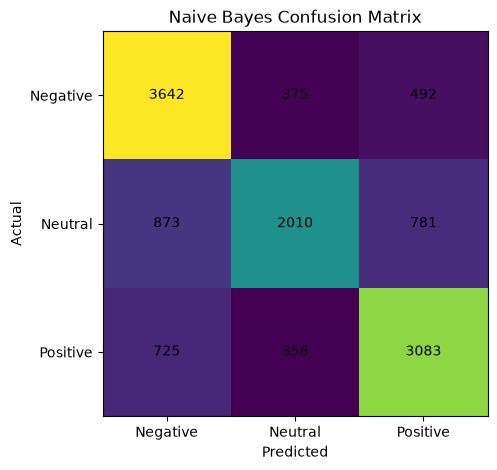

In [46]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

nb_cm = confusion_matrix(y_test, nb_pred)

plt.figure(figsize=(6, 5))
plt.imshow(nb_cm)
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(range(3), ["Negative", "Neutral", "Positive"])
plt.yticks(range(3), ["Negative", "Neutral", "Positive"])

for i in range(3):
    for j in range(3):
        plt.text(j, i, nb_cm[i, j], ha="center", va="center")

plt.show()

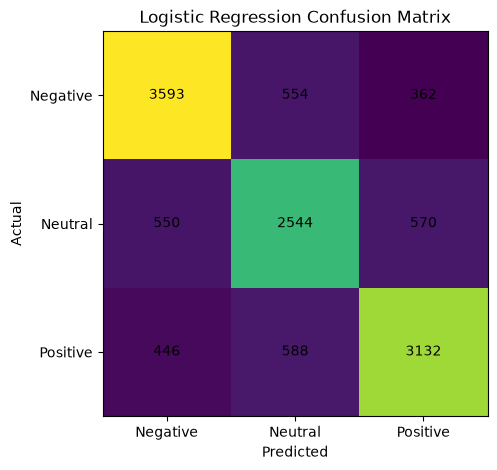

In [47]:
lr_cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6, 5))
plt.imshow(lr_cm)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(range(3), ["Negative", "Neutral", "Positive"])
plt.yticks(range(3), ["Negative", "Neutral", "Positive"])

for i in range(3):
    for j in range(3):
        plt.text(j, i, lr_cm[i, j], ha="center", va="center")

plt.show()

In [48]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [49]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

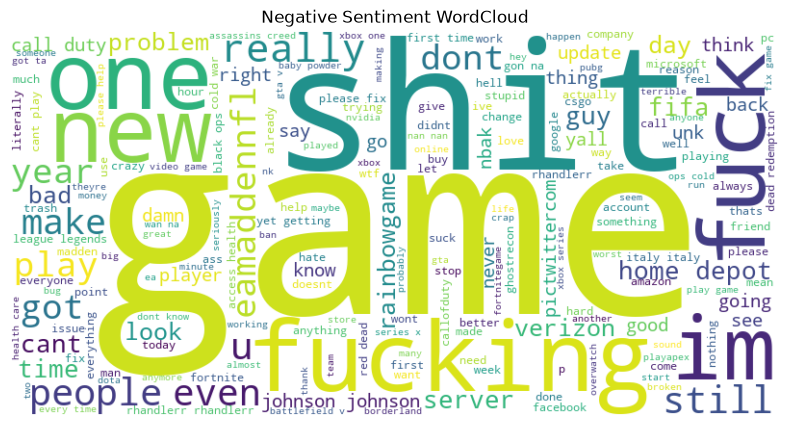

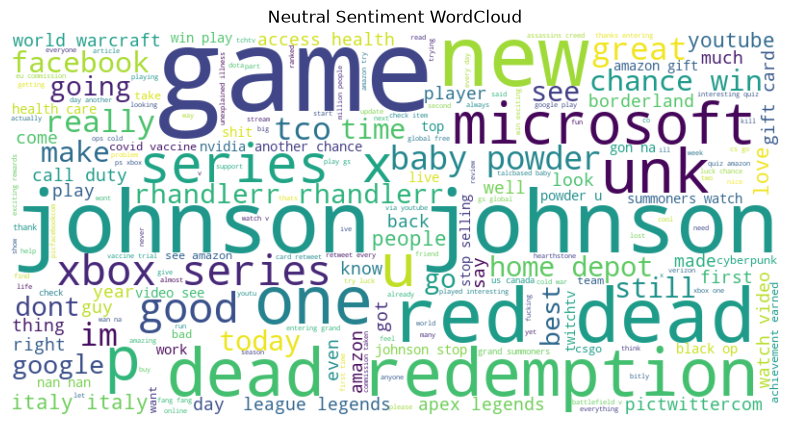

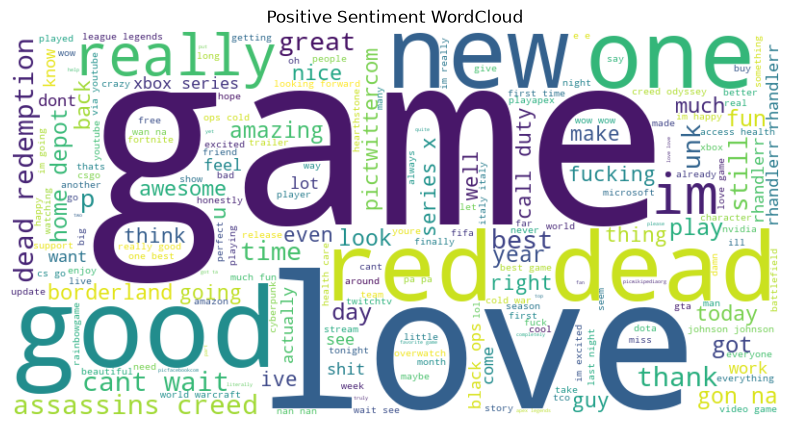

In [50]:
sentiments = ["Negative", "Neutral", "Positive"]

for sentiment in sentiments:
    text = " ".join(df[df.iloc[:, 2] == sentiment]["clean_text"])
    
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white"
    ).generate(text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"{sentiment} Sentiment WordCloud")
    plt.show()

In [51]:
test_results = pd.DataFrame({
    "text": X_test,
    "actual": y_test,
    "predicted": lr_pred
})

misclassified = test_results[
    test_results["actual"] != test_results["predicted"]
]

misclassified.head(5)

,text,actual,predicted
46350,tech question know mobile phones built eternit...,Neutral,Negative
67541,lol nice going use compare see shade foundatio...,Neutral,Positive
70310,feel like ive hardly gotten draws league latel...,Neutral,Positive
29260,,Positive,Neutral
74584,think im gon na playing around nvidia broadcas...,Neutral,Positive


## Error Analysis

The Logistic Regression model misclassified some tweets because sentiment can be difficult to determine from text alone. Some tweets contain informal language, slang, sarcasm, ambiguous wording, or limited context. These factors can make it difficult for the model to correctly identify the intended sentiment.

In [55]:
for index, row in misclassified.head(5).iterrows():
    print("INDEX:", index)
    print("TEXT:", row["text"])
    print("ACTUAL:", row["actual"])
    print("PREDICTED:", row["predicted"])
    print("-" * 80)

INDEX: 46350
TEXT: tech question know mobile phones built eternity months bought new moto e play verizon android battery suddenly empty charge quickly
ACTUAL: Neutral
PREDICTED: Negative
--------------------------------------------------------------------------------
INDEX: 67541
TEXT: lol nice going use compare see shade foundation pick
ACTUAL: Neutral
PREDICTED: Positive
--------------------------------------------------------------------------------
INDEX: 70310
TEXT: feel like ive hardly gotten draws league lately super satisfying helping get overtime w
ACTUAL: Neutral
PREDICTED: Positive
--------------------------------------------------------------------------------
INDEX: 29260
TEXT: 
ACTUAL: Positive
PREDICTED: Neutral
--------------------------------------------------------------------------------
INDEX: 74584
TEXT: think im gon na playing around nvidia broadcast stuff today professorbroman seems talking hopefully make mic sound like im duck talking tiled shower cute
ACTUAL: N

## Error Analysis

The Logistic Regression model misclassified some tweets because sentiment can be difficult to determine from text alone. Informal language, slang, missing context, and unclear wording can make sentiment classification challenging.

### Misclassified Example 1
- **Actual:** Neutral
- **Predicted:** Negative
- **Reason:** The tweet discusses a technical issue with a mobile phone battery. Words such as "empty" and "suddenly" may have caused the model to associate the tweet with negative sentiment, even though the tweet is mainly asking about a technical problem.

### Misclassified Example 2
- **Actual:** Neutral
- **Predicted:** Positive
- **Reason:** The tweet contains words such as "lol," "nice," and "pick," which can appear in positive conversations. However, the overall meaning is neutral and requires context to understand.

### Misclassified Example 3
- **Actual:** Neutral
- **Predicted:** Positive
- **Reason:** The tweet talks about playing a game and helping with overtime. Words such as "satisfying" and "helping" may have caused the model to classify it as positive, even though the overall sentiment is neutral.

### Misclassified Example 4
- **Actual:** Positive
- **Predicted:** Neutral
- **Reason:** The tweet contains no visible text after preprocessing. Without meaningful words to analyze, the model had very little information available and predicted the neutral class.

### Misclassified Example 5
- **Actual:** Neutral
- **Predicted:** Positive
- **Reason:** The tweet contains positive-sounding words such as "hopefully," "cute," and "sound," which may have influenced the model to predict positive sentiment. However, the overall tweet is mainly discussing activities and plans rather than expressing a clear positive emotion.

### Summary

These examples show that the model can struggle with informal social-media language, ambiguous statements, context-dependent meaning, and tweets with insufficient information. Better preprocessing and models that understand context could potentially improve sentiment classification.

## Conclusion

This project developed a sentiment analysis model for classifying tweets into three sentiment categories: Negative, Neutral, and Positive. The text data was preprocessed by converting text to lowercase, removing punctuation and stopwords, and tokenizing the tweets. TF-IDF was then used to convert the text into numerical features for machine learning.

Two machine learning algorithms were tested: Naive Bayes and Logistic Regression. Naive Bayes achieved an accuracy of 70.79%, while Logistic Regression achieved a higher accuracy of 75.12%. Therefore, Logistic Regression was the better-performing model among the two models tested.

Sentiment analysis can be applied in real-world situations such as analyzing customer feedback, monitoring social media opinions, tracking brand reputation, and understanding customer satisfaction. Overall, this project demonstrates how machine learning can be used to automatically classify sentiment from social media text.